Updated : 2026-06-30

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import os
%matplotlib inline

# UDFs
from src.load_config import load_json_config
from src.display import plot_forecast_comparison # Model output display

# Setup

In [28]:
# Load configuration

local_config = load_json_config("config/local.json")
schema_config = load_json_config("config/schema.json")

In [29]:
# Load data
combined_data = local_config['combined_data_path']
raw_df = pd.read_csv(combined_data)

In [30]:
# Declare variables
kpi = schema_config['kpi']

# Data Cleaning

In [31]:
raw_df["month"] = pd.to_datetime(raw_df["month"], errors="coerce")

# Data Processing


✓ Performing STL Decomposition...
✓ Performing Classical Decomposition...
✓ Performing Moving Average Decomposition...

Decomposition Complete!
   actual        trend     seasonal    residual       date
0   560.0  2551.104652 -1479.456004 -511.648648 2020-12-01
1  3031.0  2582.362288   647.205027 -198.567315 2021-01-01
2  2991.0  2612.380821  -130.103359  508.722538 2021-02-01
3  2987.0  2641.718210   283.862641   61.419150 2021-03-01
4  2904.0  2670.644832  -110.141877  343.497045 2021-04-01
5  1200.0  2699.197043 -1572.735378   73.538335 2021-05-01
6  3252.0  2726.999853   600.957516  -75.957368 2021-06-01
7  4073.0  2753.200090  1422.703233 -102.903322 2021-07-01
8  2984.0  2776.279595   354.208575 -146.488170 2021-08-01
9  2330.0  2792.948131  -277.442042 -185.506089 2021-09-01


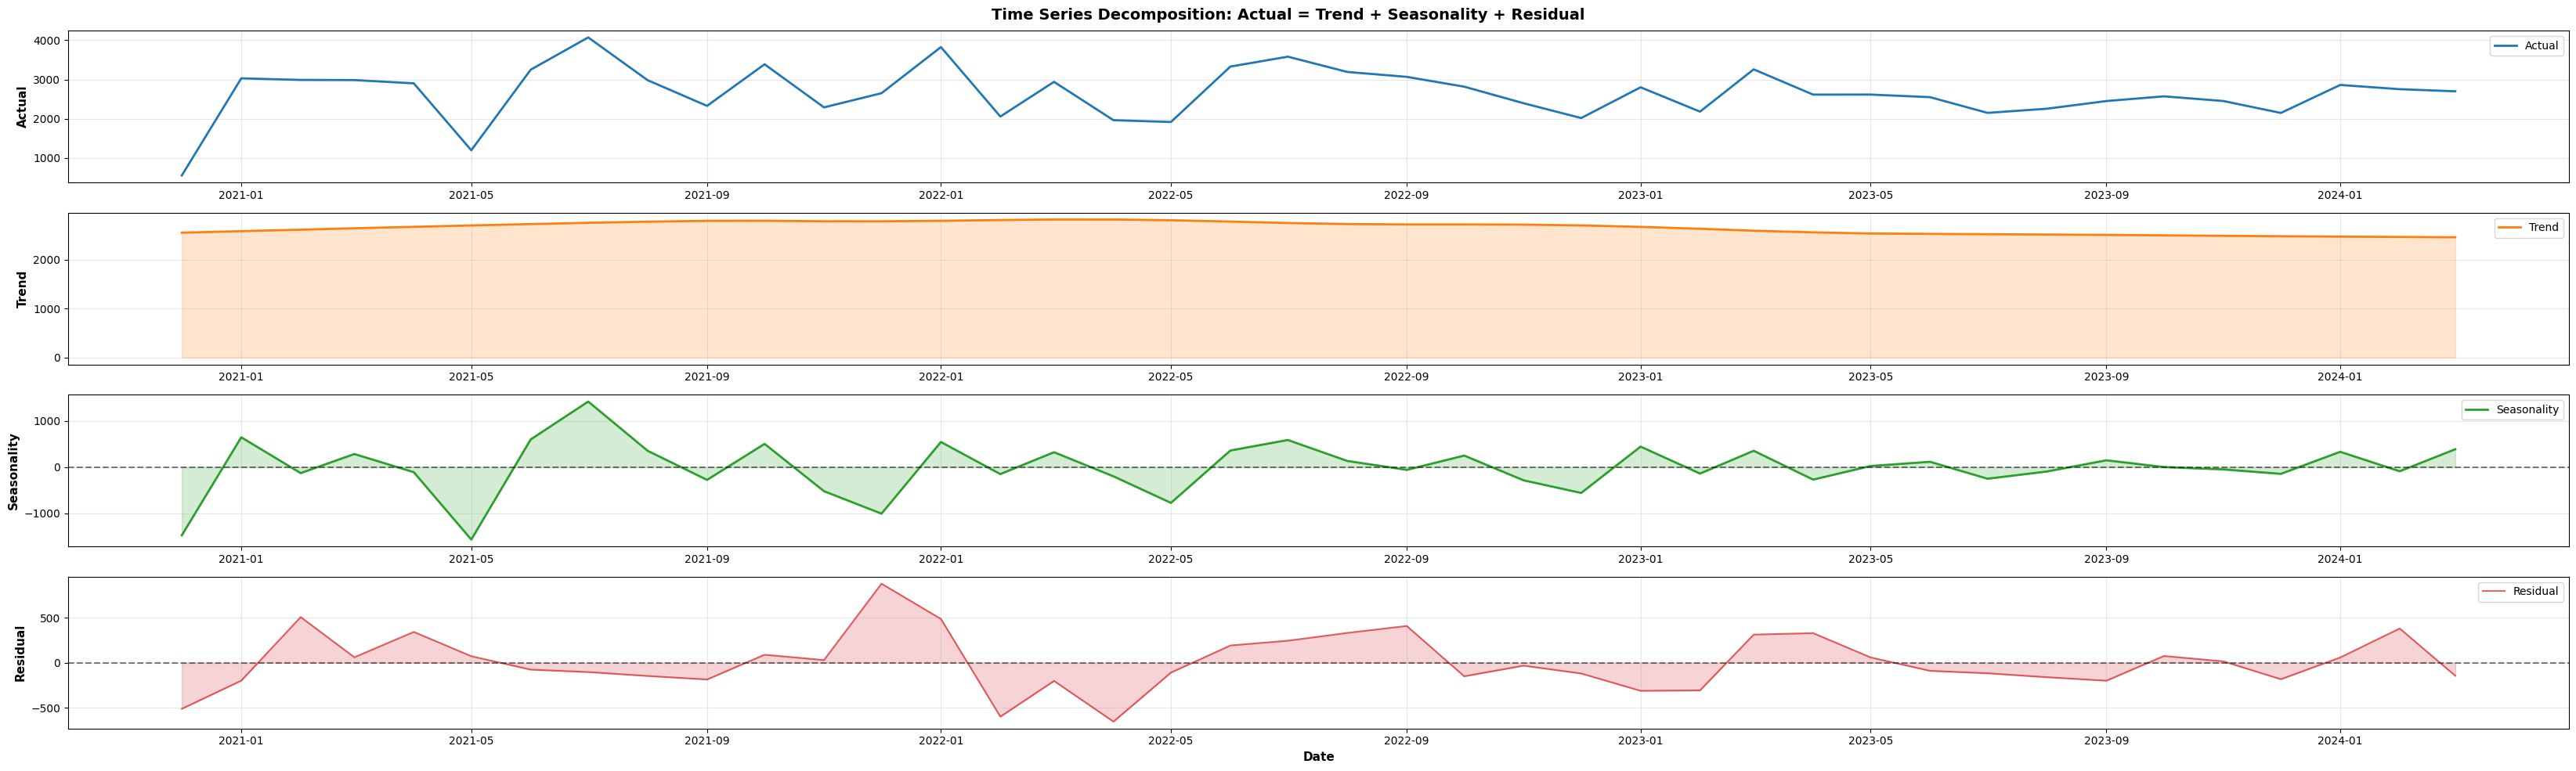

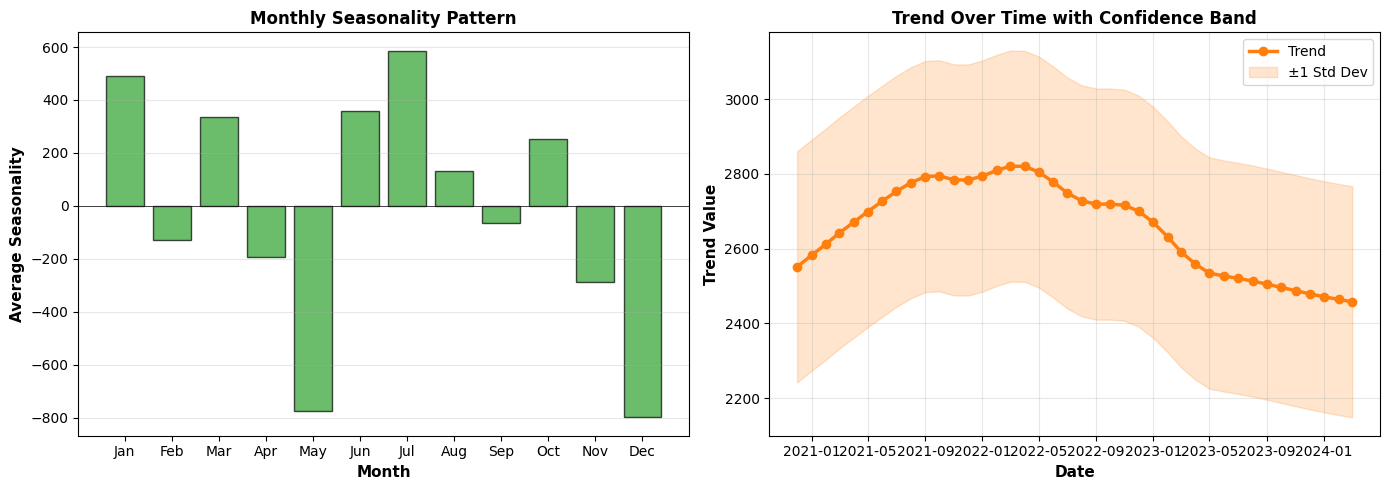


DECOMPOSITION QUALITY METRICS

📊 Variance Decomposition:
  • Total Variance (Actual):  428,694.03
  • Trend Variance:            14,999.06 (3.5%)
  • Seasonal Variance:         311,950.06 (72.8%)
  • Residual Variance:         95,643.62 (22.3%)

✓ Reconstruction Accuracy:
  • Mean Absolute Error:       0.0000
  • RMSE:                      0.0000
  • Max Error:                 0.0000

📈 Trend Strength:           13.56%
🔄 Seasonality Strength:     76.53%

📉 Residual Statistics (should be near 0, normal distribution):
  • Mean:                      7.446720
  • Std Dev:                   309.2630
  • Skewness:                  0.3457 (0 = perfect)
  • Kurtosis:                  0.5110 (0 = normal)

✓ Results exported to 'decomposition_results.csv'


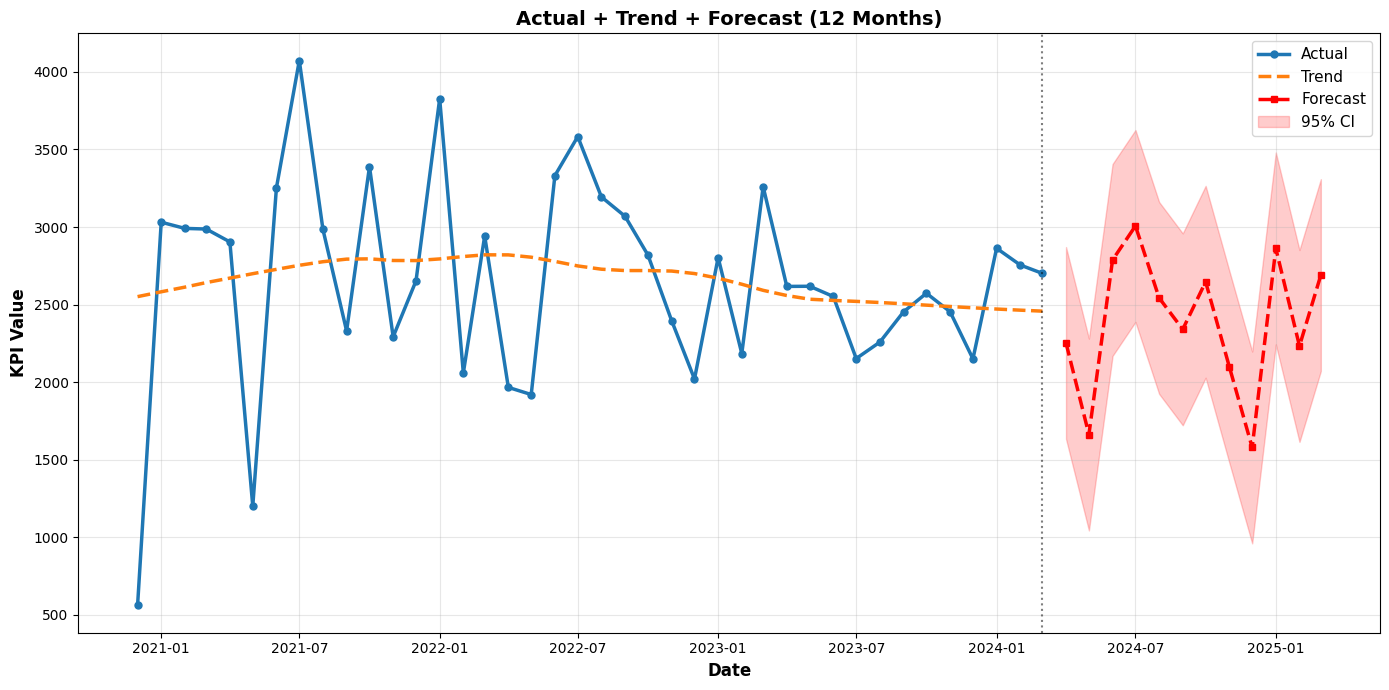


✓ ANALYSIS COMPLETE!

Generated Charts:
  1. 01_decomposition_stacked.png - Stacked components
  3. 03_seasonality_pattern.png - Monthly pattern + trend confidence band
  4. 04_forecast_chart.png - Forecast with confidence intervals


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from scipy import signal
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')


df = raw_df.copy()
df.rename(columns={'sales': 'kpi'}, inplace=True)

# Ensure valid types
df['month'] = pd.to_datetime(df['month'], errors='coerce')
df['kpi'] = pd.to_numeric(df['kpi'], errors='coerce')


# Remove rows that break decomposition/forecast functions
before_rows = len(df)
df = (
    df.dropna(subset=['month', 'kpi'])
      .sort_values('month')
      .drop_duplicates(subset=['month'], keep='last')
      .reset_index(drop=True)
)
after_rows = len(df)

# Then run the analysis code


# ==========================================
# 2. DECOMPOSITION METHODS
# ==========================================

class TimeSeriesDecomposition:
    """Comprehensive time series decomposition"""
    
    def __init__(self, df, kpi_col, date_col, period=12):
        self.df = df.sort_values(date_col).copy()
        self.kpi_col = kpi_col
        self.date_col = date_col
        self.period = period
        self.df.set_index(date_col, inplace=True)
        
    def stl_decomposition(self, seasonal=13, trend=None):
        """
        STL (Seasonal and Trend decomposition using LOESS)
        - More robust than classical decomposition
        - Better for irregular patterns
        """
        stl = STL(self.df[self.kpi_col], seasonal=seasonal, trend=trend)
        result = stl.fit()
        
        decomp_df = pd.DataFrame({
            'actual': self.df[self.kpi_col],
            'trend': result.trend,
            'seasonal': result.seasonal,
            'residual': result.resid
        })
        return decomp_df, result
    
    def classical_decomposition(self, model='additive'):
        """
        Classical decomposition
        - model: 'additive' or 'multiplicative'
        """
        result = seasonal_decompose(
            self.df[self.kpi_col],
            model=model,
            period=self.period,
            extrapolate_trend='freq'   # or an integer, e.g. 12
        )

        decomp_df = pd.DataFrame({
            'actual': self.df[self.kpi_col],
            'trend': result.trend,
            'seasonal': result.seasonal,
            'residual': result.resid
        })
        return decomp_df, result
    
    def moving_average_decomposition(self, window=3):
        """
        Simple MA-based decomposition
        - Trend: Moving average
        - Seasonality: Deviation from trend by month
        """
        actual = self.df[self.kpi_col].values
        
        # Trend
        trend = pd.Series(actual).rolling(window=window, center=True, min_periods=1).mean().values
        
        # Detrended
        detrended = actual - trend
        
        # Seasonality: Average by month
        month_numbers = self.df.index.month
        seasonality = np.zeros_like(actual, dtype=float)
        
        for month in range(1, 13):
            mask = month_numbers == month
            if mask.sum() > 0:
                seasonal_avg = np.nanmean(detrended[mask])
                seasonality[mask] = seasonal_avg
        
        # Residual
        residual = actual - trend - seasonality
        
        decomp_df = pd.DataFrame({
            'actual': actual,
            'trend': trend,
            'seasonal': seasonality,
            'residual': residual
        }, index=self.df.index)
        
        return decomp_df, None
    
    def lowess_trend(self, frac=0.15):
        """
        LOWESS trend extraction
        - frac: fraction of data to use in local regression
        """
        from statsmodels.nonparametric.smoothers_lowess import lowess
        
        x = np.arange(len(self.df))
        y = self.df[self.kpi_col].values
        
        trend_result = lowess(y, x, frac=frac)
        trend_smooth = trend_result[:, 1]
        
        return pd.Series(trend_smooth, index=self.df.index)

# ==========================================
# 3. RUN DECOMPOSITION
# ==========================================

decomposer = TimeSeriesDecomposition(df, kpi_col='kpi', date_col='month', period=12)

# Method 1: STL (Recommended - most accurate)
print("\n✓ Performing STL Decomposition...")
stl_decomp, stl_result = decomposer.stl_decomposition(seasonal=13, trend=None)

# Method 2: Classical Decomposition
print("✓ Performing Classical Decomposition...")
classical_decomp, classical_result = decomposer.classical_decomposition(model='additive')

# Method 3: Moving Average (Simple)
print("✓ Performing Moving Average Decomposition...")
ma_decomp, _ = decomposer.moving_average_decomposition(window=3)

# Use STL as primary (most accurate)
decomp = stl_decomp.copy()
decomp['date'] = decomp.index
decomp = decomp.reset_index(drop=True)

print("\nDecomposition Complete!")
print(decomp.head(10))

# ==========================================
# 4. ADVANCED VISUALIZATIONS
# ==========================================

# Color scheme
ACTUAL_COLOR = "#1f77b4"    # Blue
TREND_COLOR = "#ff7f0e"     # Orange
SEASONAL_COLOR = "#2ca02c"  # Green
RESIDUAL_COLOR = "#d62728"  # Red

# Figure 1: Complete Decomposition (Stacked)
fig, axes = plt.subplots(4, 1, figsize=(33, 10))
fig.suptitle('Time Series Decomposition: Actual = Trend + Seasonality + Residual', 
             fontsize=14, fontweight='bold')

# Actual
axes[0].plot(decomp['date'], decomp['actual'], color=ACTUAL_COLOR, linewidth=2, label='Actual')
axes[0].set_ylabel('Actual', fontsize=11, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='best')

# Trend
axes[1].plot(decomp['date'], decomp['trend'], color=TREND_COLOR, linewidth=2, label='Trend')
axes[1].fill_between(decomp['date'], decomp['trend'], alpha=0.2, color=TREND_COLOR)
axes[1].set_ylabel('Trend', fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='best')

# Seasonality
axes[2].plot(decomp['date'], decomp['seasonal'], color=SEASONAL_COLOR, linewidth=2, label='Seasonality')
axes[2].fill_between(decomp['date'], decomp['seasonal'], alpha=0.2, color=SEASONAL_COLOR)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[2].set_ylabel('Seasonality', fontsize=11, fontweight='bold')
axes[2].grid(alpha=0.3)
axes[2].legend(loc='best')

# Residual
axes[3].plot(decomp['date'], decomp['residual'], color=RESIDUAL_COLOR, linewidth=1.5, alpha=0.7, label='Residual')
axes[3].fill_between(decomp['date'], decomp['residual'], alpha=0.2, color=RESIDUAL_COLOR)
axes[3].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[3].set_ylabel('Residual', fontsize=11, fontweight='bold')
axes[3].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[3].grid(alpha=0.3)
axes[3].legend(loc='best')

plt.tight_layout()
plt.savefig(os.path.join(local_config["output_path"], 'decomposition_stacked.png'), dpi=300, bbox_inches='tight')
plt.show()

# # ==========================================
# # Figure 2: Overlay Chart (Actual + Trend + Seasonality)
# # ==========================================

# fig, ax = plt.subplots(figsize=(14, 7))

# ax.plot(decomp['date'], decomp['actual'], 
#         color=ACTUAL_COLOR, linewidth=2.5, label='Actual', alpha=0.8, marker='o', markersize=4)

# ax.plot(decomp['date'], decomp['trend'], 
#         color=TREND_COLOR, linewidth=2.5, label='Trend', linestyle='--', alpha=0.9)

# ax.plot(decomp['date'], decomp['seasonal'], 
#         color=SEASONAL_COLOR, linewidth=2, label='Seasonality', linestyle=':', alpha=0.8)

# ax.fill_between(decomp['date'], decomp['actual'], decomp['trend'], 
#                 alpha=0.1, color=SEASONAL_COLOR, label='Gap (Seasonal + Residual)')

# ax.set_xlabel('Date', fontsize=12, fontweight='bold')
# ax.set_ylabel('KPI Value', fontsize=12, fontweight='bold')
# ax.set_title('KPI: Actual vs Trend vs Seasonality', fontsize=14, fontweight='bold')
# ax.legend(loc='best', fontsize=11, framealpha=0.9)
# ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig('02_overlay_chart.png', dpi=300, bbox_inches='tight')
# plt.show()

# ==========================================
# Figure 3: Year-over-Year Seasonality Pattern
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Seasonality by Month
monthly_seasonal = decomp.copy()
monthly_seasonal['month'] = pd.to_datetime(monthly_seasonal['date']).dt.month
monthly_pattern = monthly_seasonal.groupby('month')['seasonal'].mean()

axes[0].bar(monthly_pattern.index, monthly_pattern.values, color=SEASONAL_COLOR, alpha=0.7, edgecolor='black')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_xlabel('Month', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Average Seasonality', fontsize=11, fontweight='bold')
axes[0].set_title('Monthly Seasonality Pattern', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].grid(alpha=0.3, axis='y')

# Trend Strength Over Time
axes[1].plot(decomp['date'], decomp['trend'], color=TREND_COLOR, linewidth=2.5, label='Trend', marker='o')
axes[1].fill_between(decomp['date'], 
                     decomp['trend'] - decomp['residual'].std(),
                     decomp['trend'] + decomp['residual'].std(),
                     alpha=0.2, color=TREND_COLOR, label='±1 Std Dev')
axes[1].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Trend Value', fontsize=11, fontweight='bold')
axes[1].set_title('Trend Over Time with Confidence Band', fontsize=12, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(local_config["output_path"], 'seasonality_pattern.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. STATISTICAL VALIDATION
# ==========================================

print("\n" + "="*60)
print("DECOMPOSITION QUALITY METRICS")
print("="*60)

# Variance Analysis
actual_var = decomp['actual'].var()
trend_var = decomp['trend'].var()
seasonal_var = decomp['seasonal'].var()
residual_var = decomp['residual'].var()

print(f"\n📊 Variance Decomposition:")
print(f"  • Total Variance (Actual):  {actual_var:,.2f}")
print(f"  • Trend Variance:            {trend_var:,.2f} ({100*trend_var/actual_var:.1f}%)")
print(f"  • Seasonal Variance:         {seasonal_var:,.2f} ({100*seasonal_var/actual_var:.1f}%)")
print(f"  • Residual Variance:         {residual_var:,.2f} ({100*residual_var/actual_var:.1f}%)")

# Reconstruction check (should be close to actual)
reconstructed = decomp['trend'] + decomp['seasonal'] + decomp['residual']
reconstruction_error = np.mean(np.abs(decomp['actual'] - reconstructed))
reconstruction_rmse = np.sqrt(np.mean((decomp['actual'] - reconstructed)**2))

print(f"\n✓ Reconstruction Accuracy:")
print(f"  • Mean Absolute Error:       {reconstruction_error:.4f}")
print(f"  • RMSE:                      {reconstruction_rmse:.4f}")
print(f"  • Max Error:                 {np.max(np.abs(decomp['actual'] - reconstructed)):.4f}")

# Trend Strength
trend_strength = 1 - (residual_var / (trend_var + residual_var))
print(f"\n📈 Trend Strength:           {trend_strength:.2%}")

# Seasonality Strength
seasonal_strength = 1 - (residual_var / (seasonal_var + residual_var))
print(f"🔄 Seasonality Strength:     {seasonal_strength:.2%}")

# Residual Statistics
residual_mean = decomp['residual'].mean()
residual_std = decomp['residual'].std()
from scipy import stats
residual_skew = stats.skew(decomp['residual'].dropna())
residual_kurtosis = stats.kurtosis(decomp['residual'].dropna())

print(f"\n📉 Residual Statistics (should be near 0, normal distribution):")
print(f"  • Mean:                      {residual_mean:.6f}")
print(f"  • Std Dev:                   {residual_std:.4f}")
print(f"  • Skewness:                  {residual_skew:.4f} (0 = perfect)")
print(f"  • Kurtosis:                  {residual_kurtosis:.4f} (0 = normal)")

# ==========================================
# 6. EXPORT RESULTS
# ==========================================

# Save decomposition to CSV
decomp_export = decomp[['date', 'actual', 'trend', 'seasonal', 'residual']].copy()
decomp_export.to_csv('decomposition_results.csv', index=False)
print(f"\n✓ Results exported to 'decomposition_results.csv'")

# # ==========================================
# # 7. FORECAST USING COMPONENTS
# # ==========================================

def forecast_components(decomp_df, periods=12):
    """
    Simple forecast based on trend + average seasonality
    """
    last_date = pd.to_datetime(decomp_df['date'].max())
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=periods, freq='MS')
    
    # Trend: Linear extrapolation of last 12 months
    recent_trend = decomp_df['trend'].tail(12).values
    x_train = np.arange(len(recent_trend)).reshape(-1, 1)
    y_train = recent_trend
    model = LinearRegression().fit(x_train, y_train)
    x_forecast = np.arange(len(recent_trend), len(recent_trend) + periods).reshape(-1, 1)
    trend_forecast = model.predict(x_forecast)
    
    # Seasonality: Use average monthly pattern
    decomp_df['month'] = pd.to_datetime(decomp_df['date']).dt.month
    monthly_pattern = decomp_df.groupby('month')['seasonal'].mean()
    seasonal_forecast = [monthly_pattern.get(m, 0) for m in future_dates.month]
    
    # Combine
    forecast = trend_forecast + np.array(seasonal_forecast)
    
    forecast_df = pd.DataFrame({
        'date': future_dates,
        'forecast': forecast,
        'trend': trend_forecast,
        'seasonal': seasonal_forecast
    })
    
    return forecast_df

forecast_df = forecast_components(decomp, periods=12)

# Plot with forecast
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(decomp['date'], decomp['actual'], 
        color=ACTUAL_COLOR, linewidth=2.5, label='Actual', marker='o', markersize=5)

ax.plot(decomp['date'], decomp['trend'], 
        color=TREND_COLOR, linewidth=2.5, label='Trend', linestyle='--')

# Forecast
ax.plot(forecast_df['date'], forecast_df['forecast'], 
        color='red', linewidth=2.5, label='Forecast', linestyle='--', marker='s', markersize=5)

# Confidence band
ax.fill_between(forecast_df['date'], 
               forecast_df['forecast'] - 2*decomp['residual'].std(),
               forecast_df['forecast'] + 2*decomp['residual'].std(),
               alpha=0.2, color='red', label='95% CI')

ax.axvline(x=decomp['date'].max(), color='black', linestyle=':', alpha=0.5)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('KPI Value', fontsize=12, fontweight='bold')
ax.set_title('Actual + Trend + Forecast (12 Months)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(local_config["output_path"],'forecast_chart.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("✓ ANALYSIS COMPLETE!")
print("="*60)
print("\nGenerated Charts:")
print("  1. 01_decomposition_stacked.png - Stacked components")
# print("  2. 02_overlay_chart.png - Overlay of actual, trend, seasonality")
print("  3. 03_seasonality_pattern.png - Monthly pattern + trend confidence band")
print("  4. 04_forecast_chart.png - Forecast with confidence intervals")

## Model run

In [33]:
from src.model_run import prophet_model_run

config_multivariate = schema_config['model_config_multivariate']

results = prophet_model_run(raw_df, config_multivariate)
print(f"\nMetrics: {results['metrics']}")

[INFO] Starting Prophet model run...
[INFO] KPI: sales, Date Column: month
[INFO] Multivariate: True, Split Ratio: 0.8
[INFO] Training period: (Timestamp('2020-08-01 00:00:00'), Timestamp('2023-06-01 00:00:00'))
[INFO] Test period: (Timestamp('2023-07-01 00:00:00'), Timestamp('2024-03-01 00:00:00'))
[INFO] Train size: 35, Test size: 9
[INFO] Using regressors: ['search_off_weekly', 'social_display_others']
[INFO] After dropping NaN (ds, y): Train size: 31, Test size: 9
[INFO] Filled missing values in 'search_off_weekly' with median: 14522.0000
[INFO] Filled missing values in 'social_display_others' with median: 0.0000


13:41:59 - cmdstanpy - INFO - Chain [1] start processing
13:42:18 - cmdstanpy - INFO - Chain [1] done processing


[INFO] Model fitted successfully
[INFO] Predictions generated for test period

[RESULTS]
  MAE:  2560.0187
  RMSE: 2926.0636
  MAPE: 102.52%

Metrics: {'mae': 2560.0186962831017, 'rmse': np.float64(2926.0636354000426), 'mape': np.float64(102.52482107516579), 'train_size': 31, 'test_size': 9}


## Actual Vs Predicted

Plot saved to: outputs\actual_vs_predicted.png


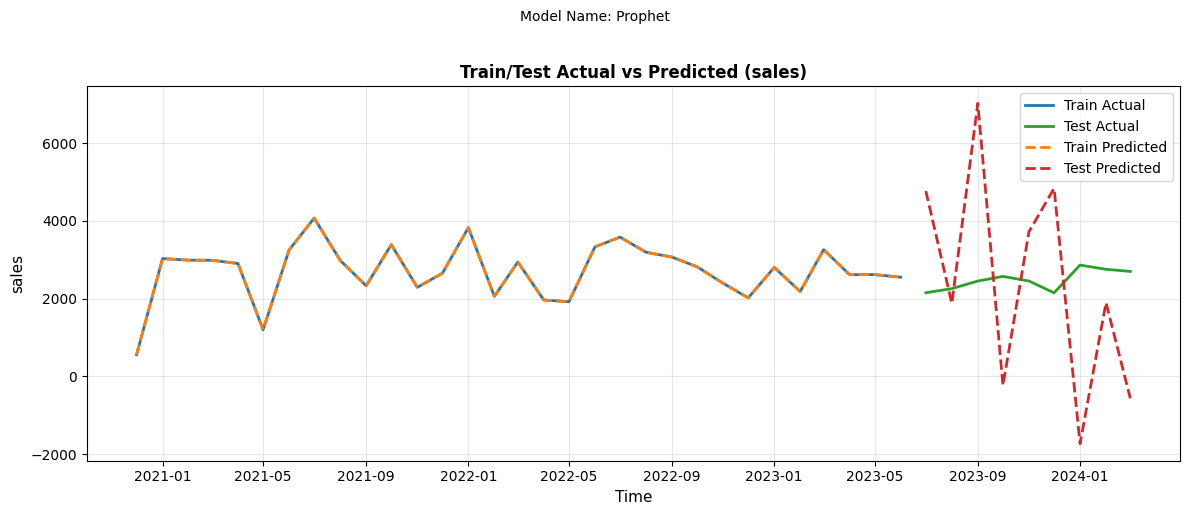

In [34]:
# Actual vs Predicted
os.makedirs(local_config["output_path"], exist_ok=True)
chart_save = os.path.join(local_config["output_path"], "actual_vs_predicted.png")

model = results['model']
train_prophet = results['train_data']
test_prophet = results['test_data']


plot_forecast_comparison(
    model,
    train_data=train_prophet,
    test_data=test_prophet,
    kpi=kpi,
    figsize=(12, 5),
    colors=None,
    save_path=chart_save,
    show_plot=True
)

In [35]:
# import os
# os.makedirs(local_config["output_path"], exist_ok=True)
# chart_save = os.path.join(local_config["output_path"], "actual_vs_predicted.png")

# print(f"Using regressors: {available_regressors}" if available_regressors else "No regressors found. Using univariate Prophet.")
# print(f"MAE:  {mae:.4f}")
# print(f"RMSE: {rmse:.4f}")

# plot_forecast_comparison(
#     model,
#     train_data=train_prophet,
#     test_data=test_prophet,
#     kpi=kpi,
#     figsize=(12, 5),
#     colors=None,
#     save_path=chart_save,
#     show_plot=True
# )

## Actual sales vs. counterfactual

Use model to perform conterfactual analysis and estimate the impact of marketing campaigns on the KPI. This involves generating a counterfactual forecast for the test period, which represents what would have happened in the absence of the marketing campaigns. The difference between the actual KPI values and the counterfactual forecast provides an estimate of the impact of the campaigns.

[INFO] Starting Prophet model run...
[INFO] KPI: sales, Date Column: month
[INFO] Multivariate: True, Split Ratio: 0.8
[INFO] Training period: (Timestamp('2020-08-01 00:00:00'), Timestamp('2023-06-01 00:00:00'))
[INFO] Test period: (Timestamp('2023-07-01 00:00:00'), Timestamp('2024-03-01 00:00:00'))
[INFO] Train size: 35, Test size: 9
[INFO] Using regressors: ['search_off_weekly', 'social_display_others']
[INFO] After dropping NaN (ds, y): Train size: 31, Test size: 9
[INFO] Filled missing values in 'search_off_weekly' with median: 14522.0000
[INFO] Filled missing values in 'social_display_others' with median: 0.0000


13:42:19 - cmdstanpy - INFO - Chain [1] start processing
13:42:35 - cmdstanpy - INFO - Chain [1] done processing


[INFO] Model fitted successfully
[INFO] Predictions generated for test period

[RESULTS]
  MAE:  2560.0187
  RMSE: 2926.0636
  MAPE: 102.52%
[INFO] Starting counterfactual impact analysis...
[INFO] Campaign regressors to zero out: ['search_off_weekly', 'social_display_others']
[INFO] Generating counterfactual forecast...
[INFO] Counterfactual forecast generated: 9 periods
[INFO] Computing incremental impact...
[INFO] Impact metrics computed
[INFO] Generating impact summary...
[INFO] Summary statistics generated
[INFO] Counterfactual impact analysis completed successfully.

COUNTERFACTUAL IMPACT ANALYSIS SUMMARY

Campaign Regressors (2):
  1. search_off_weekly
  2. social_display_others

Test Period:
  Start: 2023-07-01 00:00:00
  End: 2024-03-01 00:00:00
  Periods: 9

KPI Summary:
  Total Actual KPI: 22,359.00
  Total Counterfactual (No Campaign): 21,593.82
  Total Incremental Impact: 765.18
  Incremental Lift %: 3.54%

Period-Level Impact:
  Average: 85.02
  Median: 380.09
  Min: -4,5

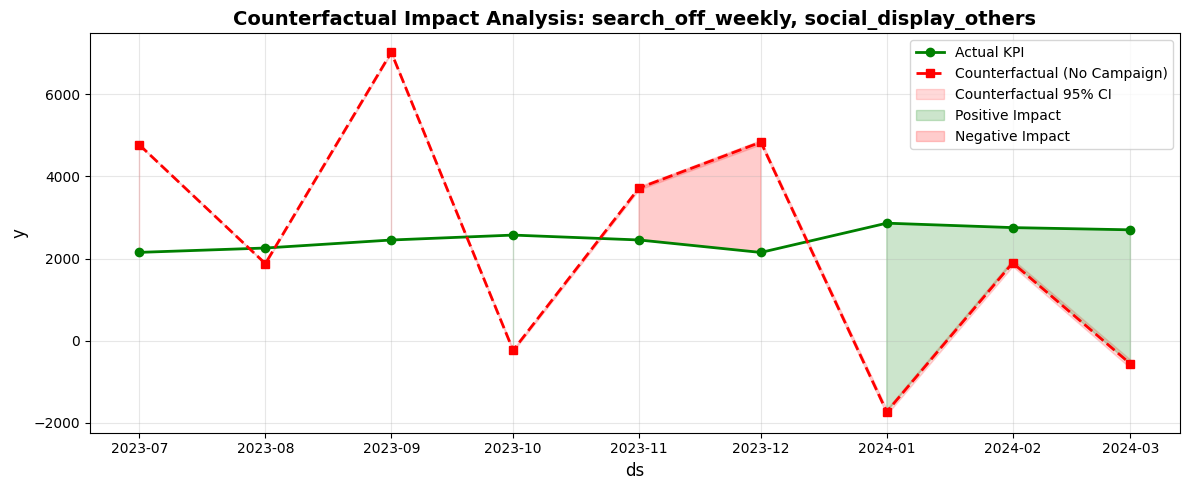

[INFO] Plot saved to outputs\counterfactual_incremental.png
[INFO] Plot saved to outputs\counterfactual_incremental.png


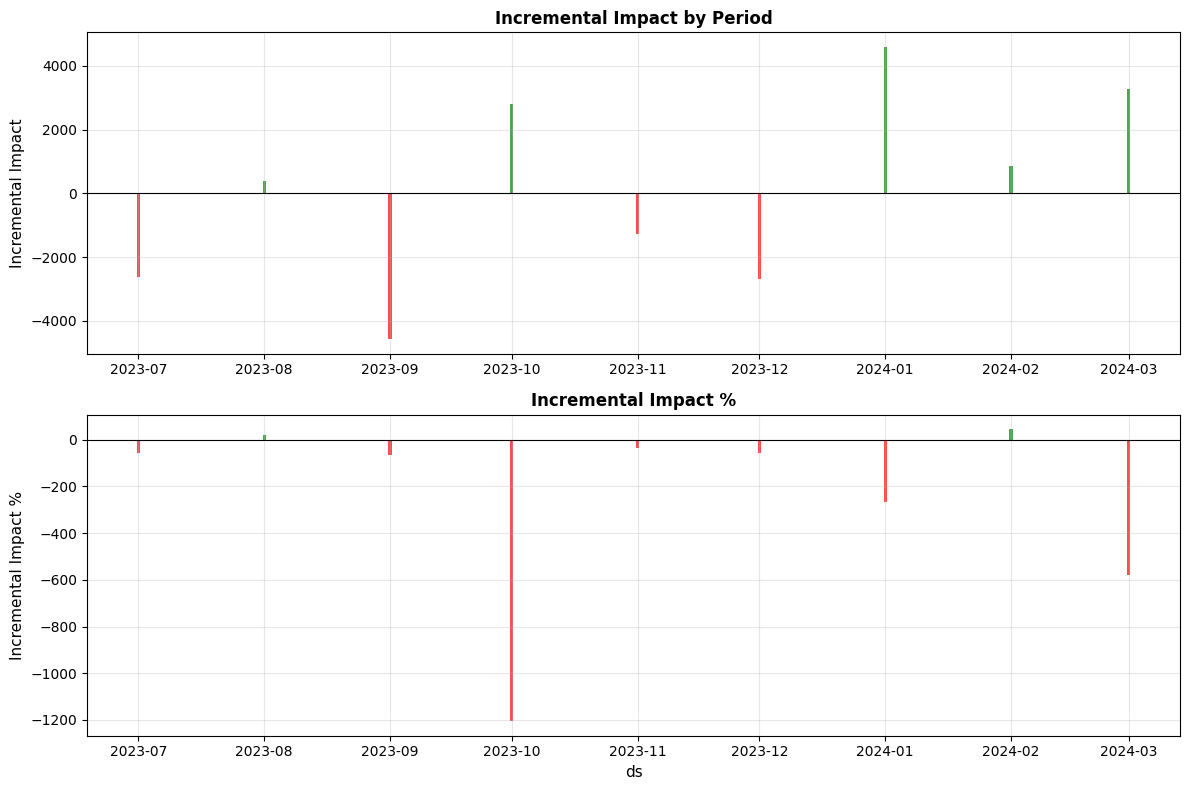

In [36]:
from src.counterfactual_analysis import CounterfactualImpactAnalyzer

config = {
    'campaign_regressors': ['search_off_weekly', 'social_display_others'],
    'test_period_col': 'ds',
    'kpi_col': 'y',
    'counterfactual_value': 0.0,
    'include_confidence_interval': True,
    'plot_enabled': True,
    'verbose': True
}

# Initialize analyzer
analyzer = CounterfactualImpactAnalyzer(config)

# Run analysis (assuming results from prophet_model_run)
results = prophet_model_run(raw_df, config_multivariate)
impact_results = analyzer.analyze(
    model=results['model'],
    test_data=results['test_data'],
    model_regressors=results['config']['regressors_used']
)

# Print summary
analyzer.print_summary()

# Export results
analyzer.export_to_csv("impact_results.csv")
analyzer.export_summary_to_json("impact_summary.json")

# Plot results
analyzer.plot_impact(save_path=os.path.join(local_config["output_path"], "counterfactual_impact.png"))  # saved as outputs\campaign_impact.png
analyzer.plot_incremental_impact(save_path=os.path.join(local_config["output_path"], "counterfactual_incremental.png"))